**Context**

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help



**Objective**

To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.



**Data Description**

The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).

**Data Dictionary**

Sl_No: Primary key of the records

Customer Key: Customer identification number

Average Credit Limit: Average credit limit of each customer for all credit cards

Total credit cards: Total number of credit cards possessed by the customer

Total visits bank: Total number of visits that the customer made (yearly) personally to the bank

Total visits online: Total number of visits or online logins made by the customer (yearly)

Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 yellowbrick==1.5 -q --user

In [2]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.2 yellowbrick==1.5 -q --user
# !pip install --upgrade -q jinja2

In [3]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [4]:
# let colab access my google drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [5]:
path = "/content/drive/MyDrive/creditcard.csv"
data=pd.read_csv(path)


## Overview of the dataset

### Displaying the first and last 5 rows of the dataset

In [7]:
data.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [8]:
data.tail()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


### Checking the shape of the dataset

In [9]:
data.shape
print(f"There are {'660'} rows and {'7'} columns.")


There are 660 rows and 7 columns.


In [10]:
data.sample(n=10, random_state=1)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
547,548,38125,26000,4,5,2,4
353,354,94437,9000,5,4,1,3
499,500,65825,68000,6,4,2,2
173,174,38410,9000,2,1,5,8
241,242,81878,10000,4,5,1,3
341,342,70779,18000,4,3,2,0
647,648,79953,183000,9,0,9,2
218,219,28208,19000,3,1,5,7
120,121,16577,10000,4,2,4,6
134,135,31256,13000,4,1,5,7


### Checking the data types of the columns for the dataset

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


### Creating a copy of original data

In [12]:
# copying the data to another variable to avoid any changes to original data
df= data.copy()

### Checking for duplicate values

In [13]:
data.duplicated().sum()

np.int64(0)

### Checking for missing values

In [14]:
data.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


### Statistical summary of the dataset

In [15]:
data.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500000,190.669872,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.443939,25627.772200,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242424,37625.487804,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706061,2.167835,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403030,1.631813,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606061,2.935724,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583333,2.865317,0.0,1.00,3.0,5.00,10.0


> There appears to be 5 duplicates in the customer key

## Analyzing the records with duplicate customer keys

In [8]:
data[data['Customer Key'].isin(data[data['Customer Key'].duplicated()]['Customer Key'].tolist())].sort_values('Customer Key')

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
48,49,37252,6000,4,0,2,8
432,433,37252,59000,6,2,1,2
332,333,47437,17000,7,3,1,0
4,5,47437,100000,6,0,12,3
411,412,50706,44000,4,5,0,2
541,542,50706,60000,7,5,2,2
391,392,96929,13000,4,5,0,0
398,399,96929,67000,6,2,2,2
104,105,97935,17000,2,1,2,10
632,633,97935,187000,7,1,7,0


> The records for same Customer Key look really different from each other. I am assuming this is either mistake in the Customer Key assignment, or we are missing `current_version_indicator` in the dataset. As of now, I am going to consider these as two different customers. After the clustering, I will analyze the groups corresponding to these sets of records

## Standardizing Column Names

In [7]:
def feature_name_standardize(df: pd.DataFrame):
    df_ = df.copy()
    df_.columns = [i.replace(" ", "_").lower() for i in df_.columns]
    return df_

In [6]:
# Dropping 'ID' type of column
data = data.drop(['Customer Key', 'Sl_No'], axis=1)

In [8]:
df=data.copy()

## Exploratory data Analysis

## Univariate Analysis

In [11]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (8,5))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=df, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        df[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        df[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [12]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

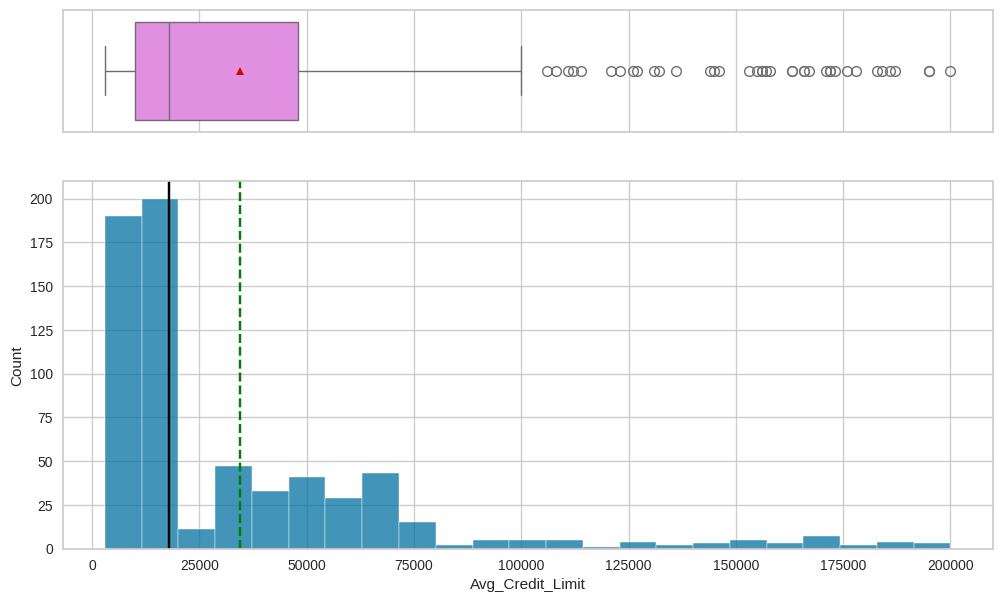

In [13]:
# Avg_Credit_Limit
histogram_boxplot(df,('Avg_Credit_Limit'))

**Comment:**

- Skew: Right
- Normal distribution: No
- Outliers: Right

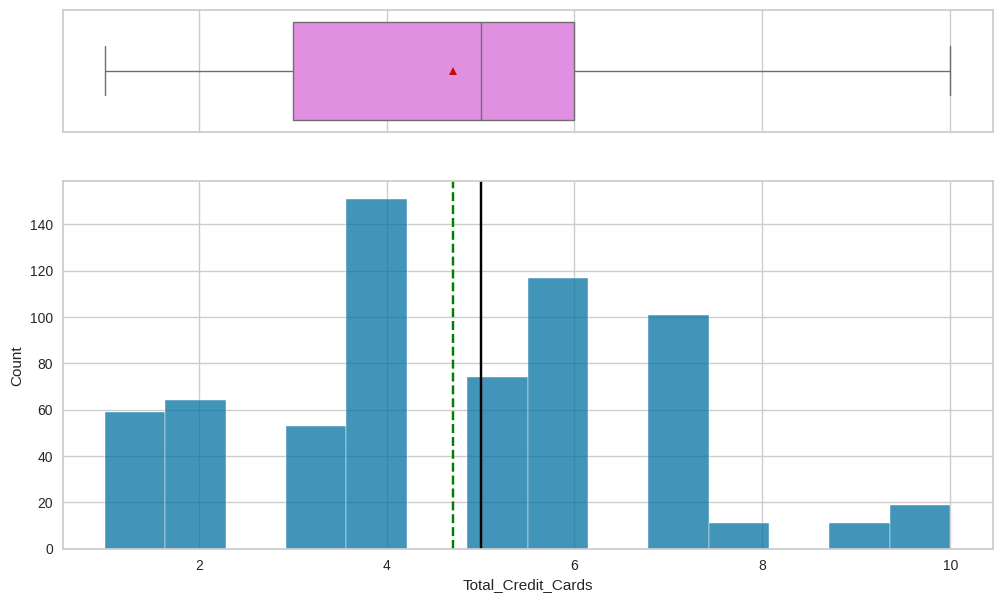

In [14]:
# Total_Credit_Cards
histogram_boxplot(df, 'Total_Credit_Cards')

**Comment:**

- Skew: left
- Normal distribution: No
- Outliers: No

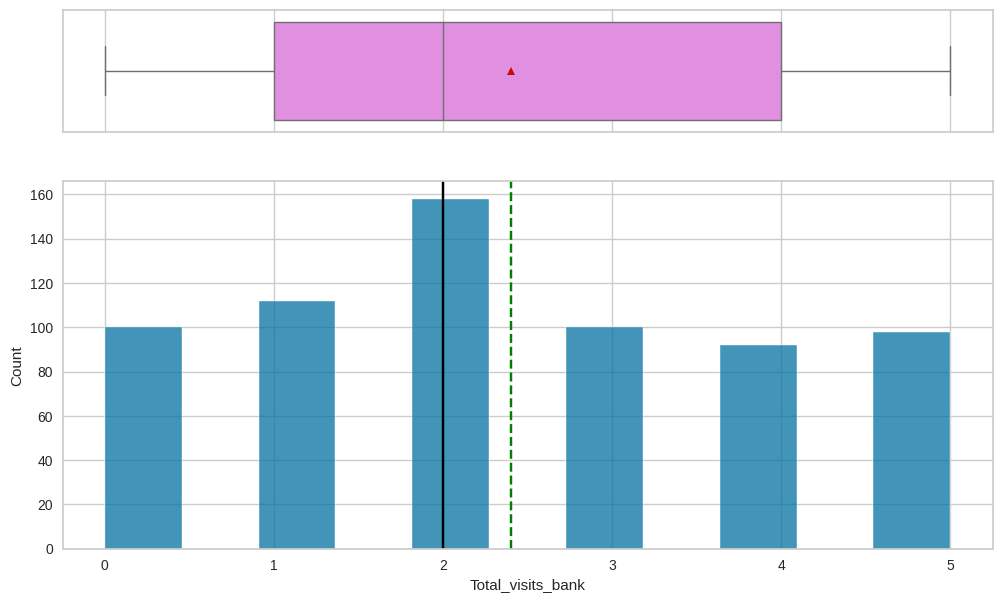

In [15]:
# Total_visits_bank
histogram_boxplot(df, 'Total_visits_bank')

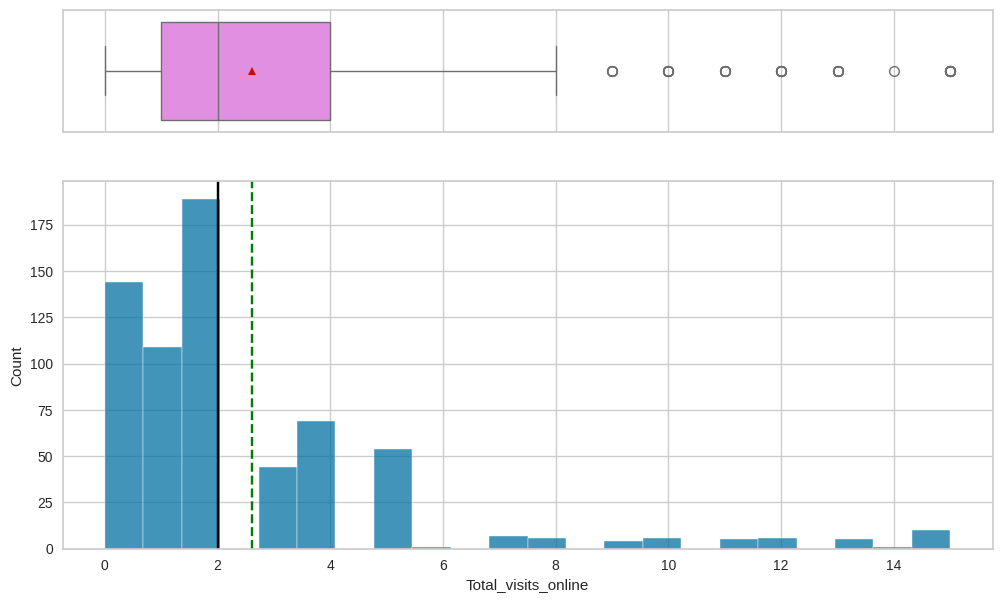

In [16]:
# Total_visits_online
histogram_boxplot(df, 'Total_visits_online')

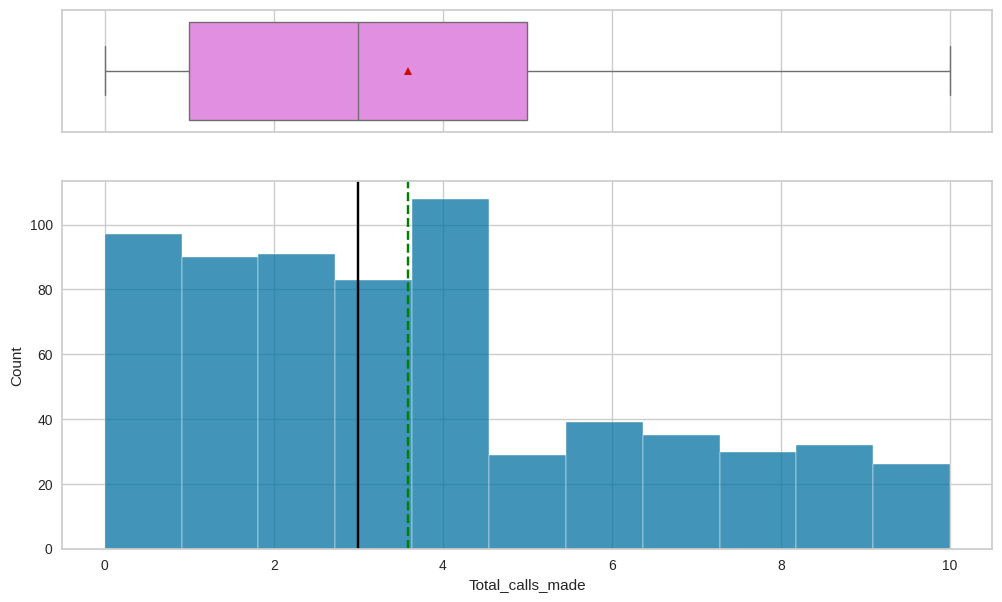

In [17]:
# Total_Calls_made
histogram_boxplot(df, 'Total_calls_made')

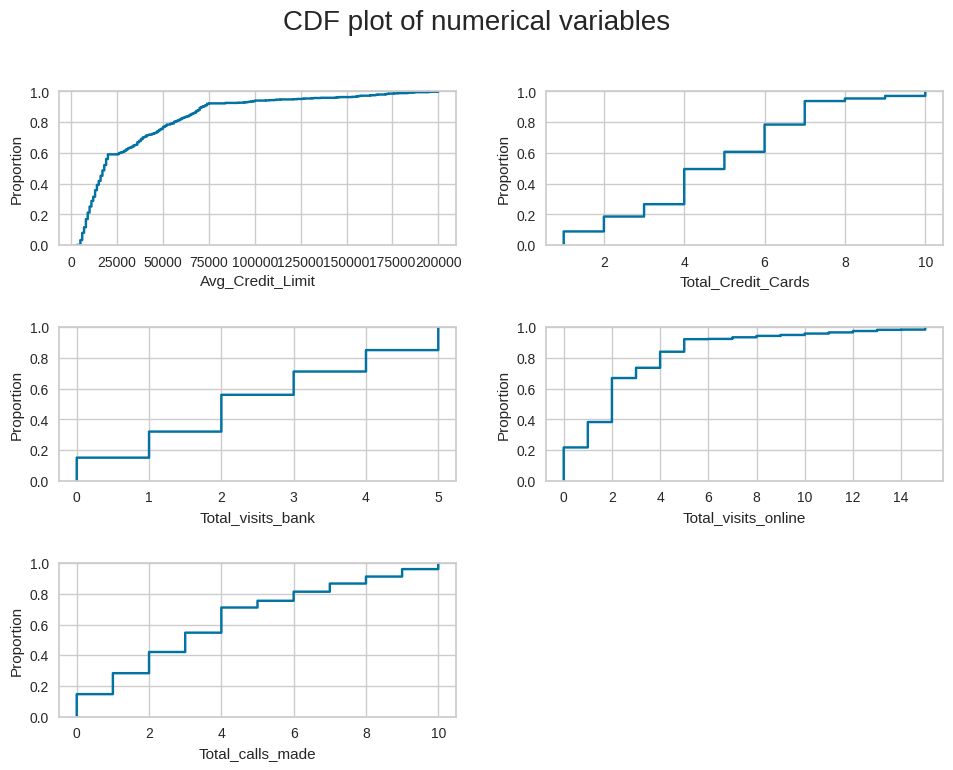

In [18]:
# select numerical columns
all_col = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(3, 2,  figsize=(10, 8))
fig.suptitle('CDF plot of numerical variables', fontsize=20)
counter = 0
for ii in range(3):
    sns.ecdfplot(ax=axes[ii][0],x=df[all_col[counter]])
    counter = counter+1
    if counter != 5:
        sns.ecdfplot(ax=axes[ii][1],x=df[all_col[counter]])
        counter = counter+1
    else:
        pass
axes[2,1].set_axis_off();


fig.tight_layout(pad=2.0)

## Labeled Bar-plots

### Credit Card Limit Bins

In [22]:
df['cc_spending_bin'] = pd.cut(data['Avg_Credit_Limit'], bins=[3000,	10000,	18000, 	48000,	200000]
                                ,labels=['Very Low', 'Low', 'Mid', 'High'], include_lowest=True)


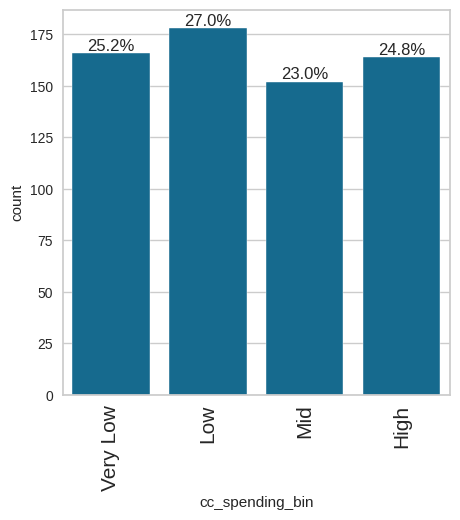

In [23]:
labeled_barplot(df, 'cc_spending_bin', perc=True)

### Total Credit Cards

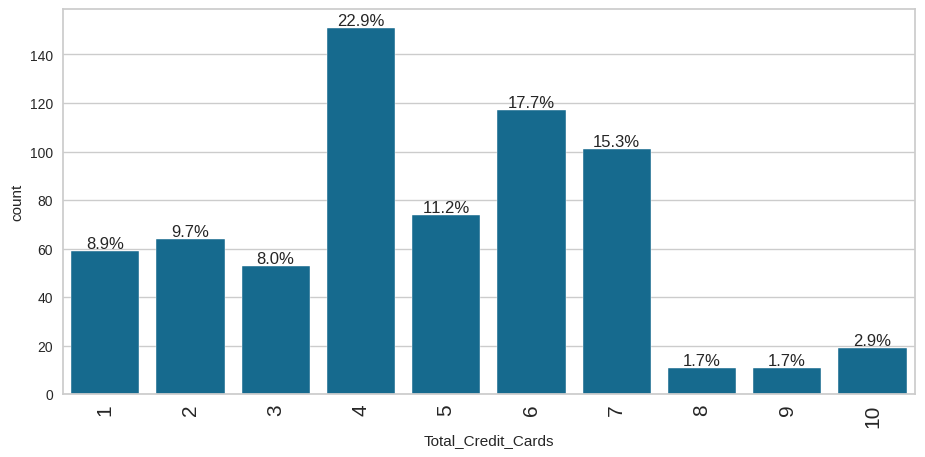

In [24]:
labeled_barplot(df, 'Total_Credit_Cards', perc=True)

### Total Visits to the Bank

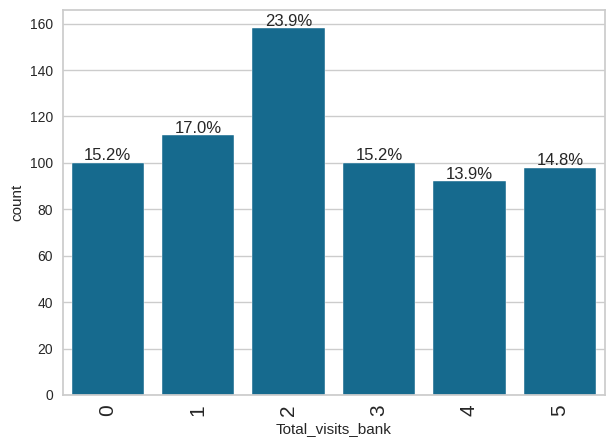

In [25]:
labeled_barplot(df, 'Total_visits_bank', perc=True)

### Total Online Visits

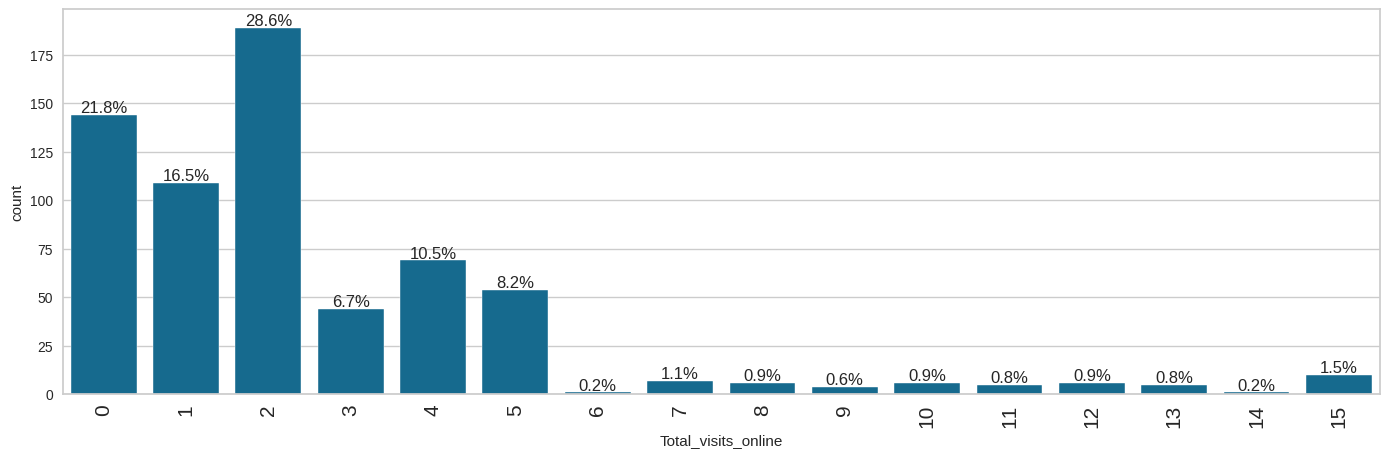

In [26]:
labeled_barplot(df, 'Total_visits_online', perc=True)

### Total Calls Made

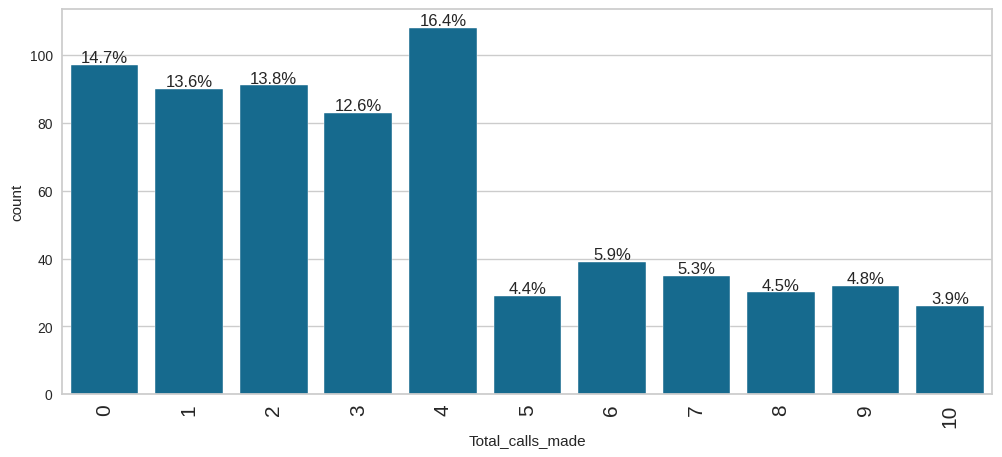

In [27]:
labeled_barplot(df, 'Total_calls_made', perc=True)

## Bi-variate Analysis

### Pair Plot

<Figure size 1000x1000 with 0 Axes>

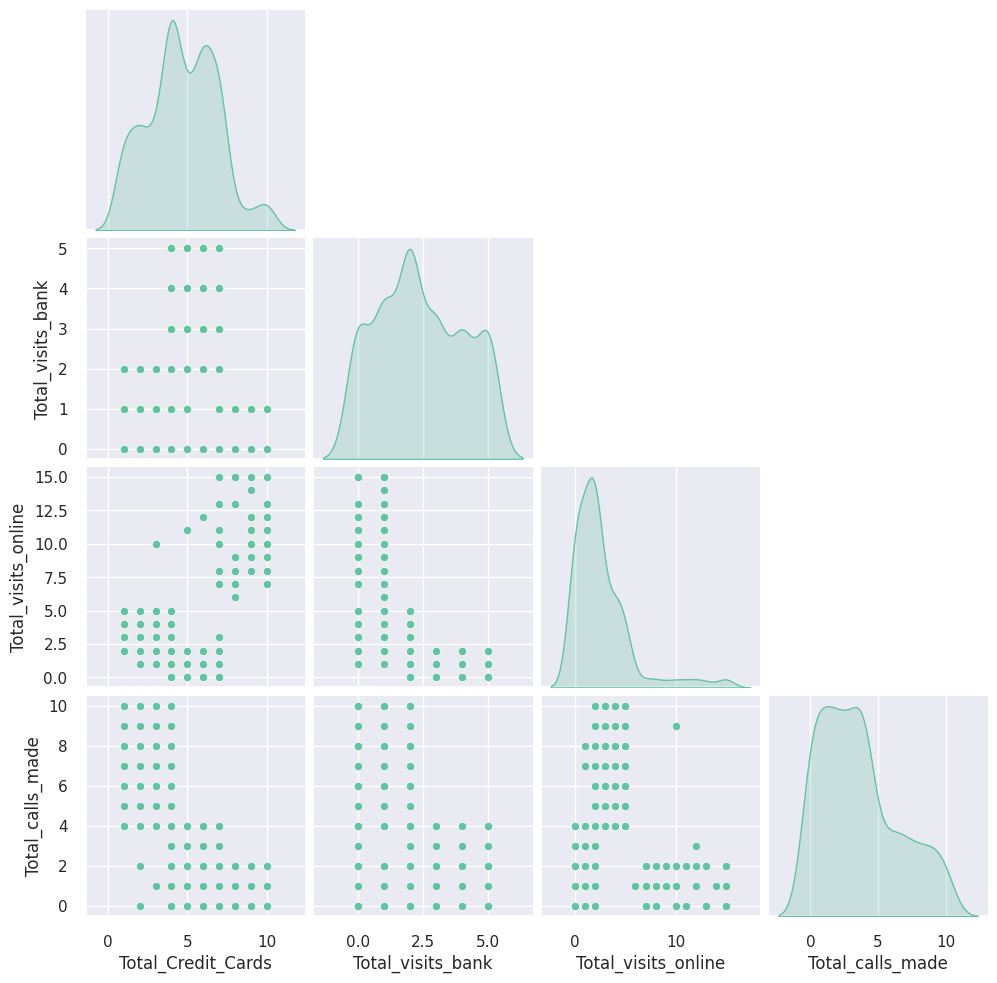

In [28]:
plt.figure(figsize=(10,10));
sns.set(palette="Set2");
sns.pairplot(data.iloc[:, 1:], diag_kind='kde', corner=True);

### Heatmap

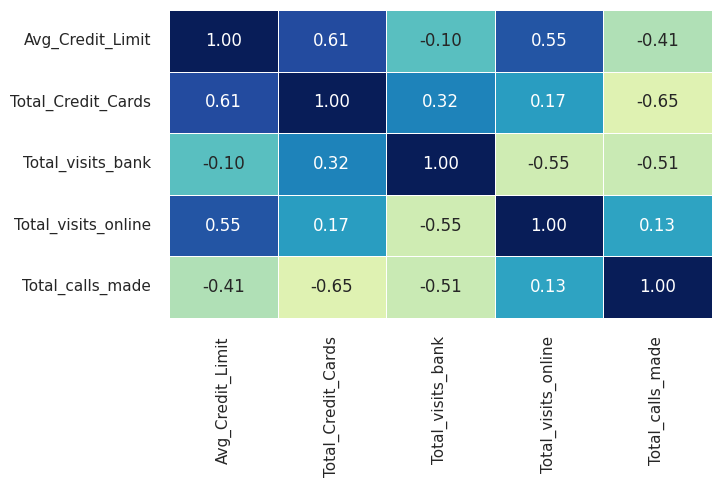

In [29]:
plt.figure(figsize=(7,4))

sns.heatmap(df[all_col].corr(),
            annot=True,
            linewidths=.5,
            center=0,
            cbar=False,
            cmap="YlGnBu",
            fmt='0.2f')

plt.show()

* `'Avg_Credit_Limit'` vs. `'Total_calls_made'` Negative correlated
* `'Avg_Credit_Limit':` vs. `'Total_visits_online'` Positive correlated
* `'Avg_Credit_Limit':` vs. `'Total_Credit_Cards'` Positive correlated
* `'Total_calls_made'` vs. `'Total_Credit_Cards'` Negative correlated
* `'Total_visits_bank'` vs. `'Total_Credit_Cards'` Positive correlated
* `'Total_visits_bank'` vs. `'Total_visits_online'` Negative correlated
* `'Total_visits_bank'` vs. `'Total_calls_made'` Negative correlated

* There is no correlations above +/- 0.75 threshold

### Average Credit Limit distribution by Each of the Other Attributes

In [30]:
# Function to plot numerical feature by each category with target hue

def plot_numeric_by_cat(data: pd.DataFrame, category_columns: list, numeric_column: str, hue: str = None):
    '''
    The function plots a numerical feature in box plot by every category column specified in the list,
    with hue of a target category
    '''
    num_cols = 2
    num_rows = int(len(category_columns) /2 + 1)

    plt.figure(figsize=(20, 8*num_rows))
    for i, col in enumerate(category_columns):
        plt.subplot(num_rows, num_cols, i+1)
        sns.set(palette="nipy_spectral");
        sns.boxplot(data=data, x=col, y=numeric_column, hue=hue, showfliers=True).set(title = numeric_column + ' vs. ' + col );

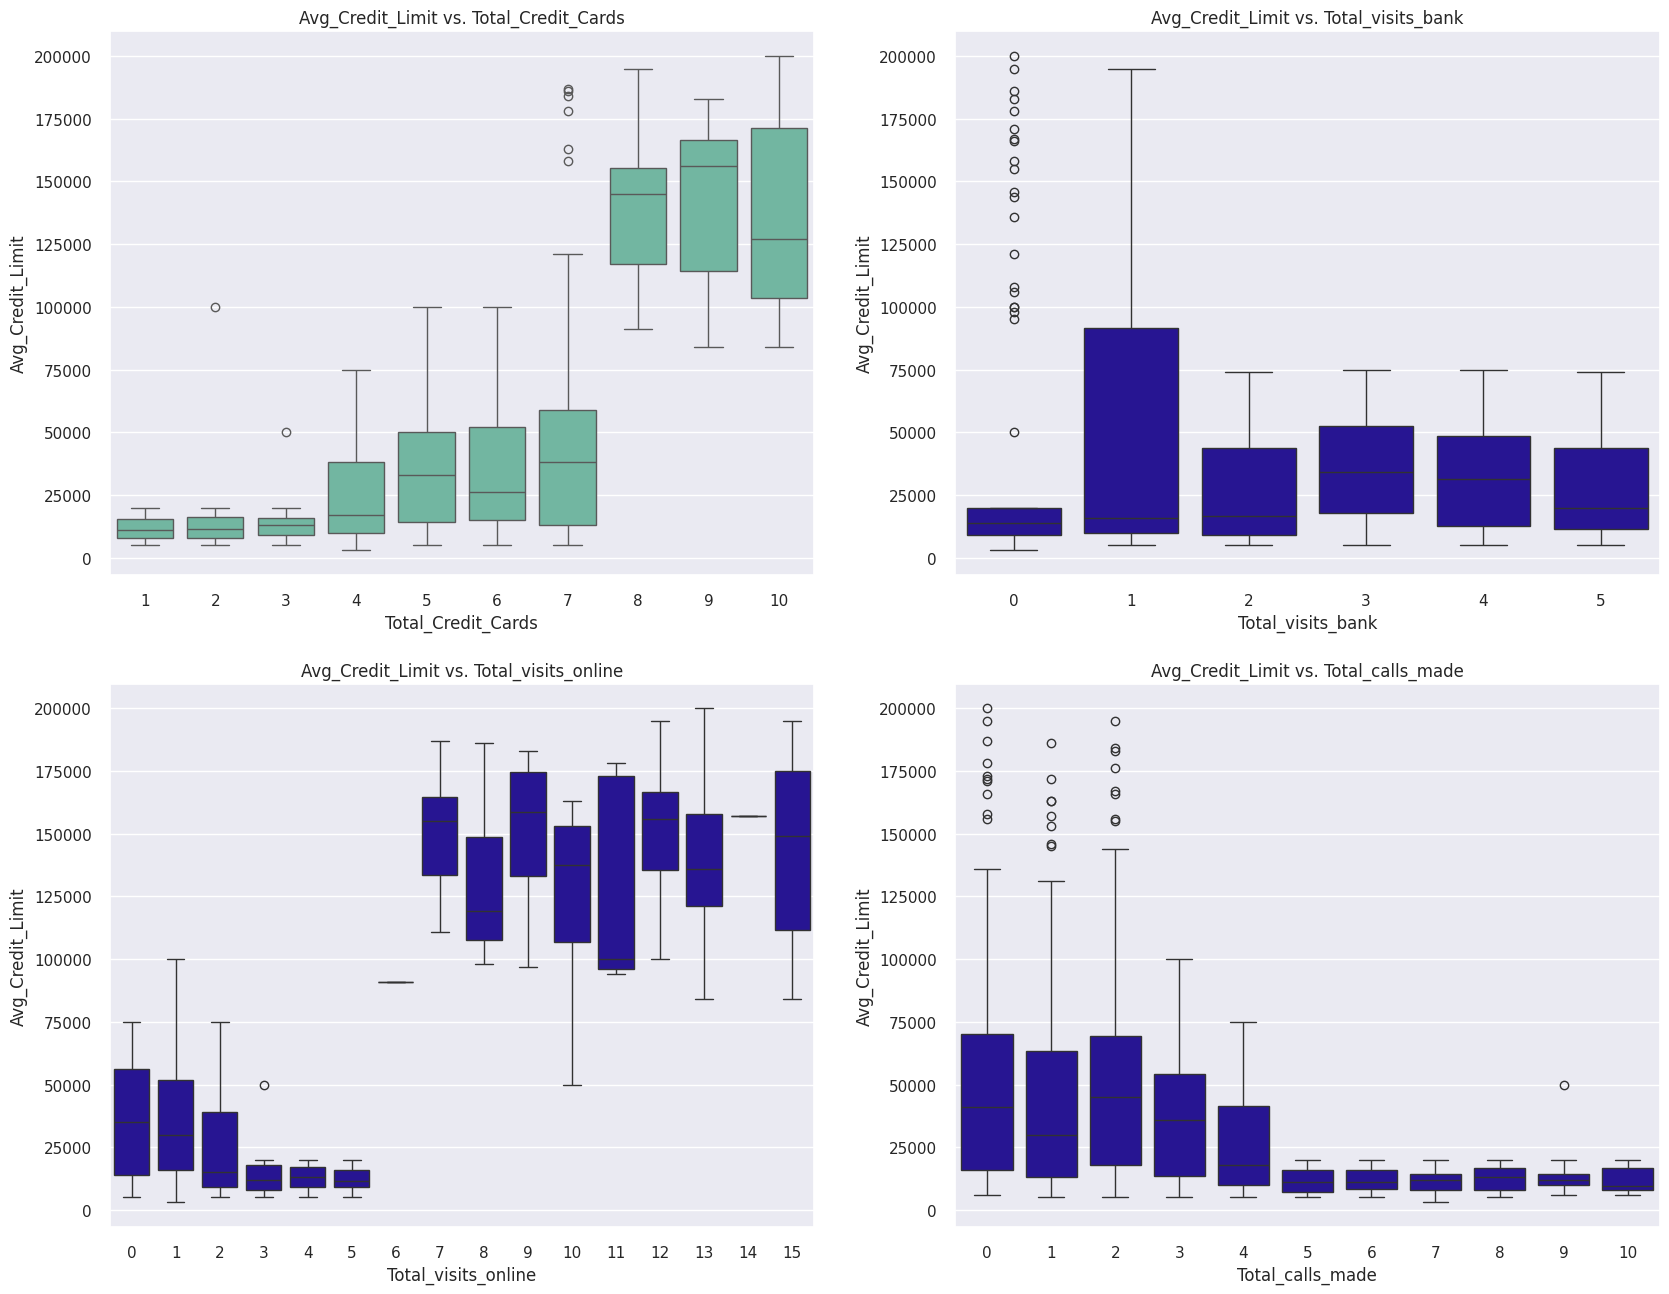

In [31]:
plot_numeric_by_cat(data\
                    ,category_columns=['Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']\
                    ,numeric_column='Avg_Credit_Limit')

> We can see clear segmentations with respect to each pair of features

## Data pre-processing

### Outliers Treatment

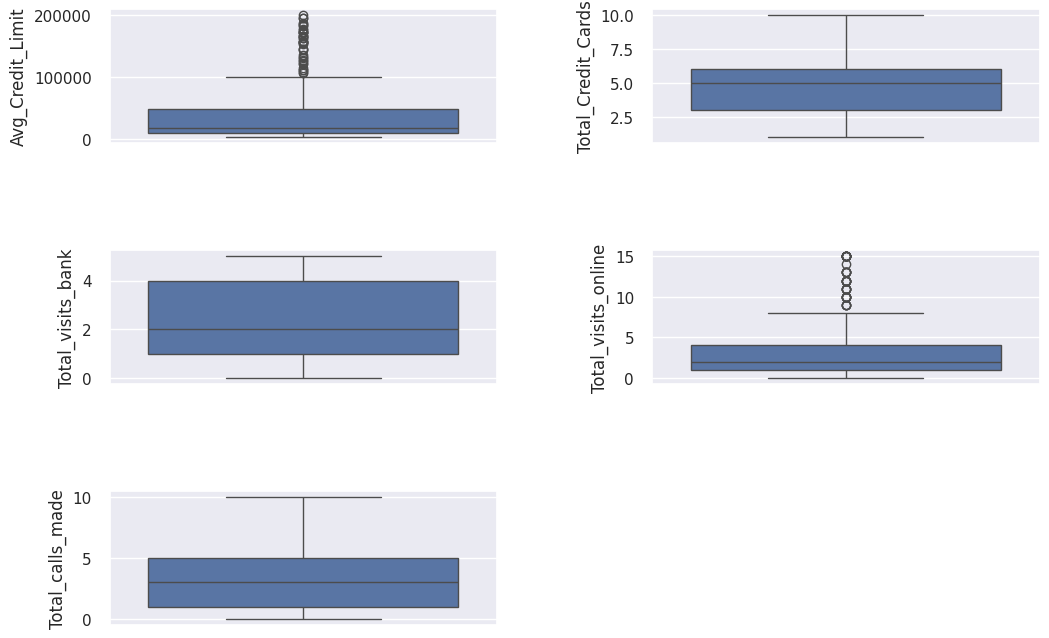

In [32]:
# Visually checking distributions
sns.set(font_scale=1)
numerical_col = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3,2, figsize=(12,8))
fig.subplots_adjust(hspace=0.8, wspace=0.4)
for axis, element in zip(axes.flat, numerical_col):
    sns.boxplot(df[element], ax=axis)
axes[2,1].set_axis_off();

In [33]:
# Lets treat outliers by flooring and capping
def treat_outliers(df,col):
    '''
    treats outliers in a variable
    df: data frame
    col: name of the feature
    '''

    # Defining quantiles:
    # 25th quantile
    Q1=df[col].quantile(0.25)

    # 75th quantile
    Q3=df[col].quantile(0.75)

    # Inter quantile Q3 - Q1;
    IQR=Q3-Q1

    # Base quantile less 1.5*IQR
    Lower_Whisker = Q1 - 1.5*IQR
    if Lower_Whisker < 0:
        Lower_Whisker = 0


    # Top quantile plus 1.5*IQR
    Upper_Whisker = Q3 + 1.5*IQR


    # assigning max and min value to the array, meaning that outliers will be subscribed by:
    # min (Lower_Whisker)
    # max (Upper_Whisker)
    df[col] = np.clip(df[col], Lower_Whisker, Upper_Whisker)

    # returning clipped data
    return df

def treat_outliers_all(df, col_list):
    '''
    treat outlier in all numerical variables
    col_list: list of numerical variables
    df: data frame
    '''
    # Looping through the data and applying the function "treat_outliers"
    for c in col_list:
        df = treat_outliers(df,c)

    return df

In [34]:
# Applying the outliers treatment
numerical_col = df.select_dtypes(include=np.number).columns.tolist()
numerical_col

['Avg_Credit_Limit',
 'Total_Credit_Cards',
 'Total_visits_bank',
 'Total_visits_online',
 'Total_calls_made']

In [35]:
# passing the columns and the dataframe in order to remove outliers
df_outliers_treated = treat_outliers_all(df,numerical_col)

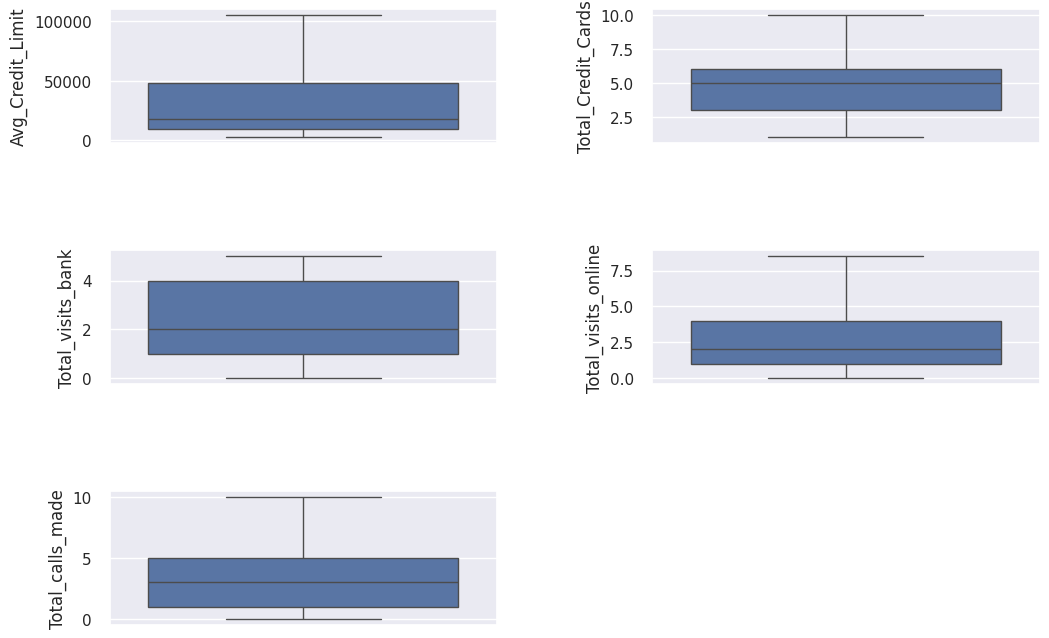

In [36]:
# Visually checking distributions
sns.set(font_scale=1)
numerical_col = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3,2, figsize=(12,8))
fig.subplots_adjust(hspace=0.8, wspace=0.4)
for axis, element in zip(axes.flat, numerical_col):
    sns.boxplot(df[element], ax=axis)
axes[2,1].set_axis_off();

In [37]:
# Saving new dataframe
df_outliers = df_outliers_treated.copy()

### Scaling the data

In [38]:
# scaling the dataset before clustering
df_copy = df.copy()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df.iloc[:,1:-1])

## K-means Clustering

K-means is often referred to as Lloyd’s algorithm. In basic terms, the algorithm has three steps. The first step chooses the initial centroids, with the most basic method being to choose samples from the dataset . After initialization, K-means consists of looping between the two other steps. The first step assigns each sample to its nearest centroid. The second step creates new centroids by taking the mean value of all of the samples assigned to each previous centroid. The difference between the old and the new centroids are computed and the algorithm repeats these last two steps until this value is less than a threshold. In other words, it repeats until the centroids do not move significantly.

### Checking Elbow Plot

In [39]:
subset_scaled_df = data_scaled

Number of Clusters: 1 	Average Distortion: 1.8569181638321428
Number of Clusters: 2 	Average Distortion: 1.3020433364900688
Number of Clusters: 3 	Average Distortion: 1.030593548506446
Number of Clusters: 4 	Average Distortion: 0.9763562180290667
Number of Clusters: 5 	Average Distortion: 0.8663072277834751
Number of Clusters: 6 	Average Distortion: 0.8264271514086979
Number of Clusters: 7 	Average Distortion: 0.7967401506483801
Number of Clusters: 8 	Average Distortion: 0.771400978884801


Text(0.5, 1.0, 'Selecting k with the Elbow Method')

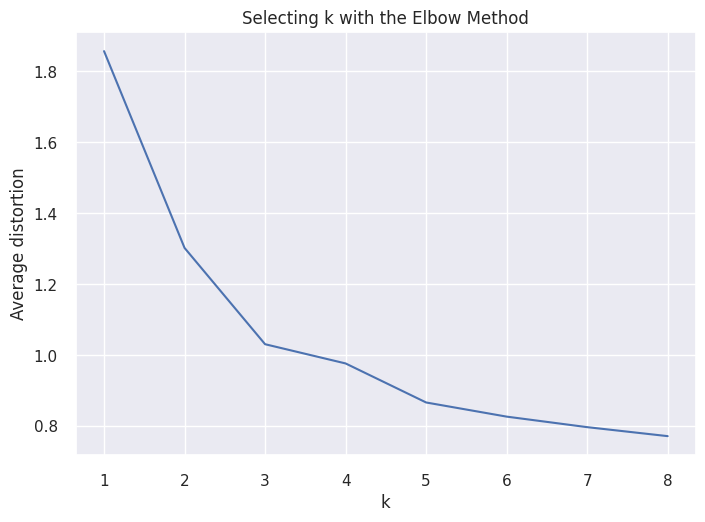

In [40]:
clusters=range(1,9)
meanDistortions=[]

for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(subset_scaled_df)
    prediction=model.predict(subset_scaled_df)
    distortion=sum(np.min(cdist(subset_scaled_df, model.cluster_centers_, 'euclidean'), axis=1)) / subset_scaled_df.shape[0]

    meanDistortions.append(distortion)

    print('Number of Clusters:', k, '\tAverage Distortion:', distortion)

plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Average distortion')
plt.title('Selecting k with the Elbow Method')

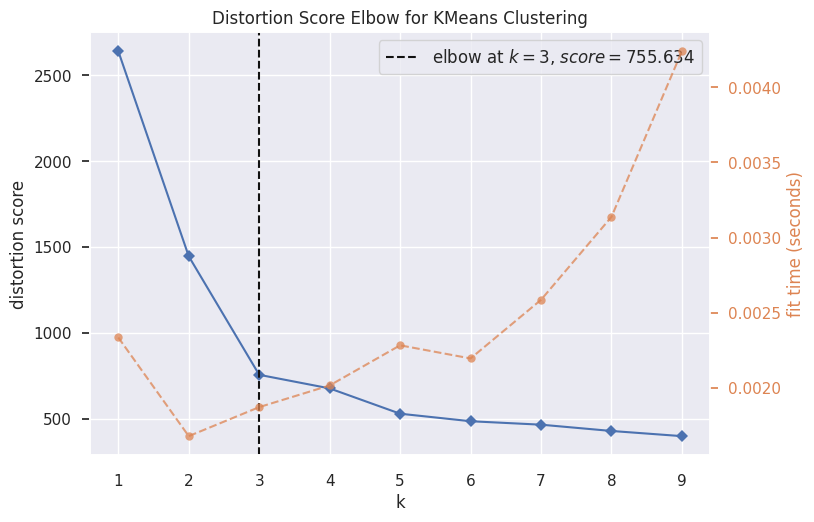

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [41]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(1, 10), timings=True)
visualizer.fit(subset_scaled_df)
visualizer.show()

**Appropriate k seems to be a 2 or 3.**

### Let's check the silhouette scores


$$\text{silhouette score}=\frac{p-q}{max(p,q)}$$

$p$ is the mean distance to the points in the nearest cluster that the data point is not a part of

$q$ is the mean intra-cluster distance to all the points in its own cluster.

* The value of the silhouette score range lies between -1 to 1.

* A score closer to 1 indicates that the data point is very similar to other data points in the cluster,

* A score closer to -1 indicates that the data point is not similar to the data points in its cluster.

For n_clusters = 2, silhouette score is 0.4652541177717367)
For n_clusters = 3, silhouette score is 0.5526215708935214)
For n_clusters = 4, silhouette score is 0.33593040816717806)
For n_clusters = 5, silhouette score is 0.30917551212817207)
For n_clusters = 6, silhouette score is 0.3131340733129509)
For n_clusters = 7, silhouette score is 0.25832248019775994)
For n_clusters = 8, silhouette score is 0.2455387312389492)
For n_clusters = 9, silhouette score is 0.26350976136024473)


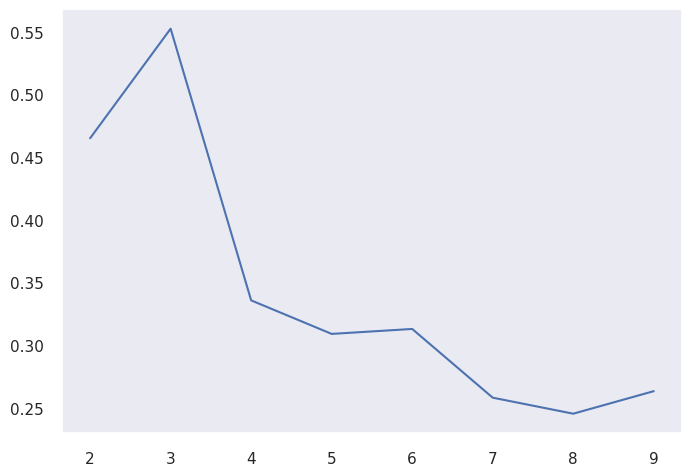

In [42]:
sil_score = []
cluster_list = list(range(2,10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((subset_scaled_df))
    #centers = clusterer.cluster_centers_
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list,sil_score)
plt.grid()

**Silhouette score for 3 is the highest.**

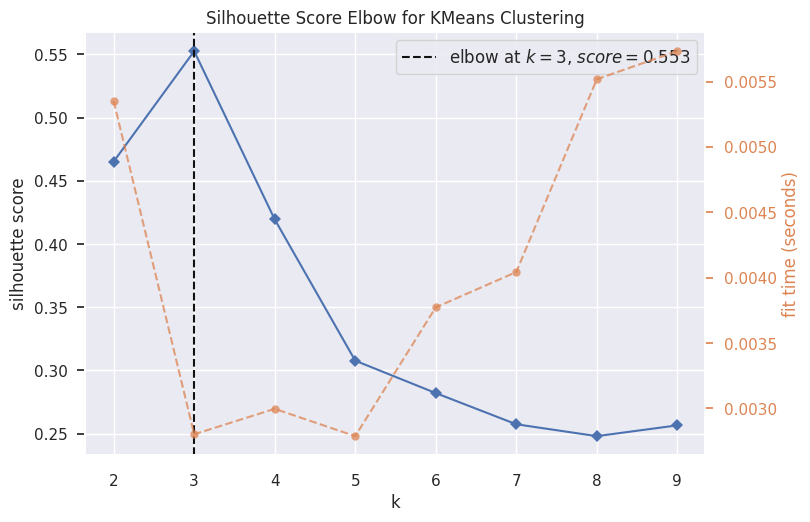

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [43]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 10), metric="silhouette", timings=True)
visualizer.fit(subset_scaled_df)
visualizer.show()

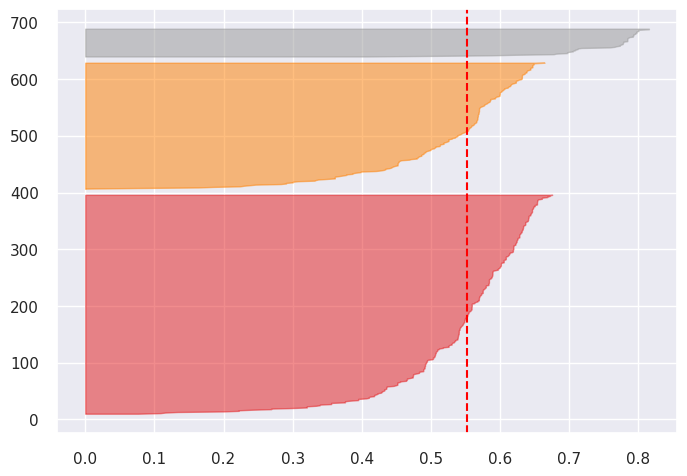

In [44]:
# Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(3, random_state = 1))
visualizer.fit(subset_scaled_df);
# visualizer.show();

**Cluster 2 seems to be too thin in comparison to the others.**

**Cluster 1 seems to be too large in comparison to the others.**

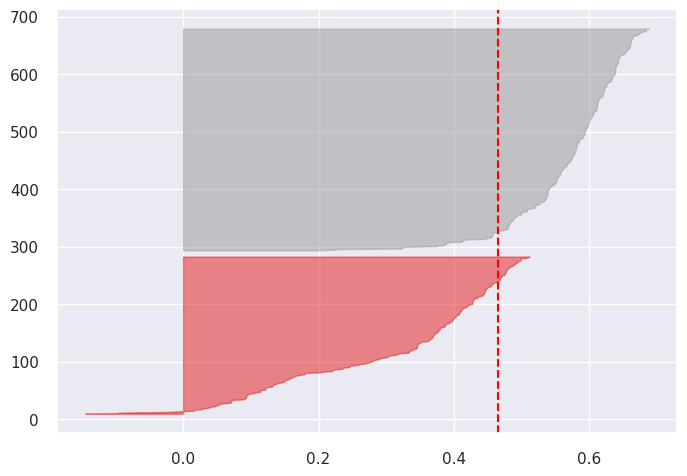

In [45]:
#Finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(2, random_state = 1))
visualizer.fit(subset_scaled_df);
# visualizer.show();

**Let us take 3 as appropriate no. of clusters as silhoutte score is high enough and there is knick at 3 in elbow curve.**

### Creating Final Model

In [46]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=3, random_state=0)

In [47]:
df_outliers['K_means_segments'] = kmeans.labels_

### Cluster Profiling

In [55]:
cluster_profile = df_outliers.groupby('K_means_segments').agg({col: 'mean' for col in df_outliers.select_dtypes(include=np.number).columns})

In [56]:
cluster_profile

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments
K_means_segments,,,,,,
0,33713.178295,5.511628,3.485788,0.984496,2.005168,0.0
1,12197.309417,2.403587,0.928251,3.553812,6.883408,1.0
2,102660.000000,8.740000,0.600000,8.180000,1.080000,2.0


In [57]:
cluster_profile['Freq'] = df_outliers.groupby('K_means_segments')['Avg_Credit_Limit'].count().values

In [58]:
# lets display cluster profile
cluster_profile.style.highlight_max(color = 'lightgreen', axis = 0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments,Freq
K_means_segments,,,,,,,
0,33713.178295,5.511628,3.485788,0.984496,2.005168,0.000000,387
1,12197.309417,2.403587,0.928251,3.553812,6.883408,1.000000,223
2,102660.000000,8.740000,0.600000,8.180000,1.080000,2.000000,50


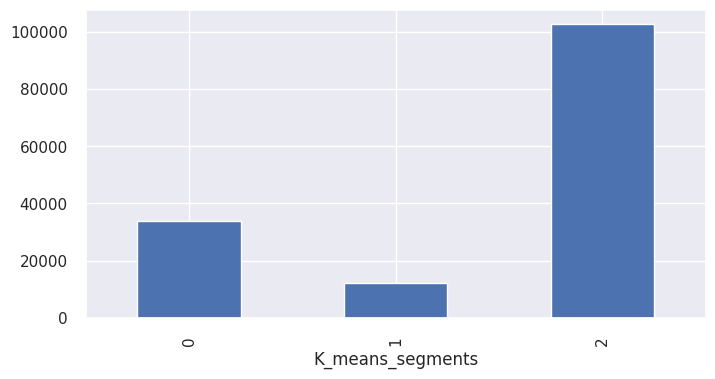

In [59]:
# Checking the groups for Avg_Credit_Limit
cluster_profile['Avg_Credit_Limit'].groupby('K_means_segments').mean().plot.bar(figsize=(8,4));

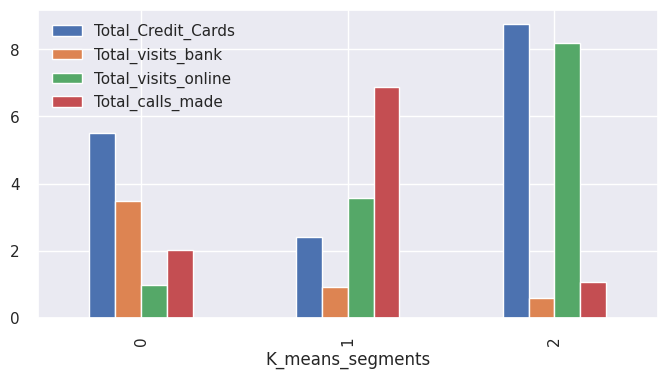

In [60]:
# Checking the groups for the remainder features
cluster_profile[['Total_Credit_Cards', 'Total_visits_bank',
       'Total_visits_online', 'Total_calls_made']].groupby('K_means_segments').mean().plot.bar(figsize=(8,4));

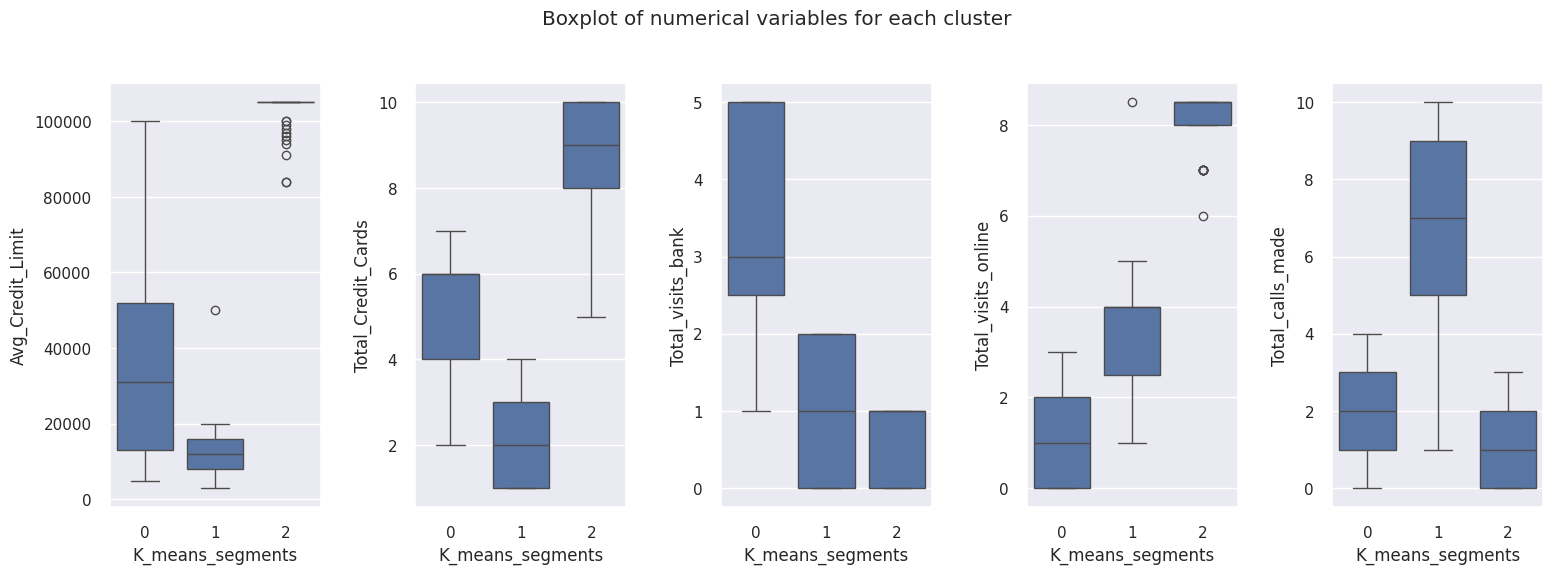

In [61]:
list_columns =  cluster_profile.columns
fig, axes = plt.subplots(1, 5,  figsize=(16, 6))
fig.suptitle('Boxplot of numerical variables for each cluster')
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii],y=df_outliers[list_columns[counter]],x=df_outliers['K_means_segments'])
    counter = counter+1

fig.tight_layout(pad=2.0)

#### **Insights K-means**
- Cluster 0 :
    - `Avg_Credit_Limit:` The mid end type of client.
    - `Total_Credit_Cards:` The mid end type of client.
    - `Total_visits_bank:` Visit the most the bank.
    - `Total_visits_online:` Doesn't access much the online bank.
    - `Total_calls_made:` Don't call as much as expected.
- Cluster 1 :
    - `Avg_Credit_Limit:` The lowest end type of client.
    - `Total_Credit_Cards:` The lowest end type of client.
    - `Total_visits_bank:` Doesn't visit much the bank.
    - `Total_visits_online:` Average end in terms of online banking usage.
    - `Total_calls_made:` The highest end type of client.
- Cluster 2 :
    - `Avg_Credit_Limit:` The highest end type of client.
    - `Total_Credit_Cards:` The highest end type of client.
    - `Total_visits_bank:` The lowest end type of client.
    - `Total_visits_online:` The highest end type of client.
    - `Total_calls_made:` The lowest end type of client.



## Hierarchical Clustering

### Computing Cophenetic Correlation

In [62]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(subset_scaled_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.5793552227318304.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8017415363599278.
Cophenetic correlation for Euclidean distance and average linkage is 0.8754213235963605.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8533487396635736.
Cophenetic correlation for Chebyshev distance and single linkage is 0.5951176691159092.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.7890411069256983.
Cophenetic correlation for Chebyshev distance and average linkage is 0.8719243247720396.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.8461513874307116.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.5711624097238523.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.46625156562786335.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.7918400674730148.
Cophenetic c

In [86]:
print('Highest cophenet correlation is {}, which is obtinaed with {} distance metric and {} linkage method'.format(high_cophenet_corr ,high_dm_lm[0],high_dm_lm[1]))

Highest cophenet correlation is 0.8700139916471747, which is obtinaed with euclidean distance metric and average linkage method


### Checking Dendrograms

We see that the cophenetic correlation is maximum with Euclidean distance and average linkage.

Let's view the dendrograms for the different linkage methods.

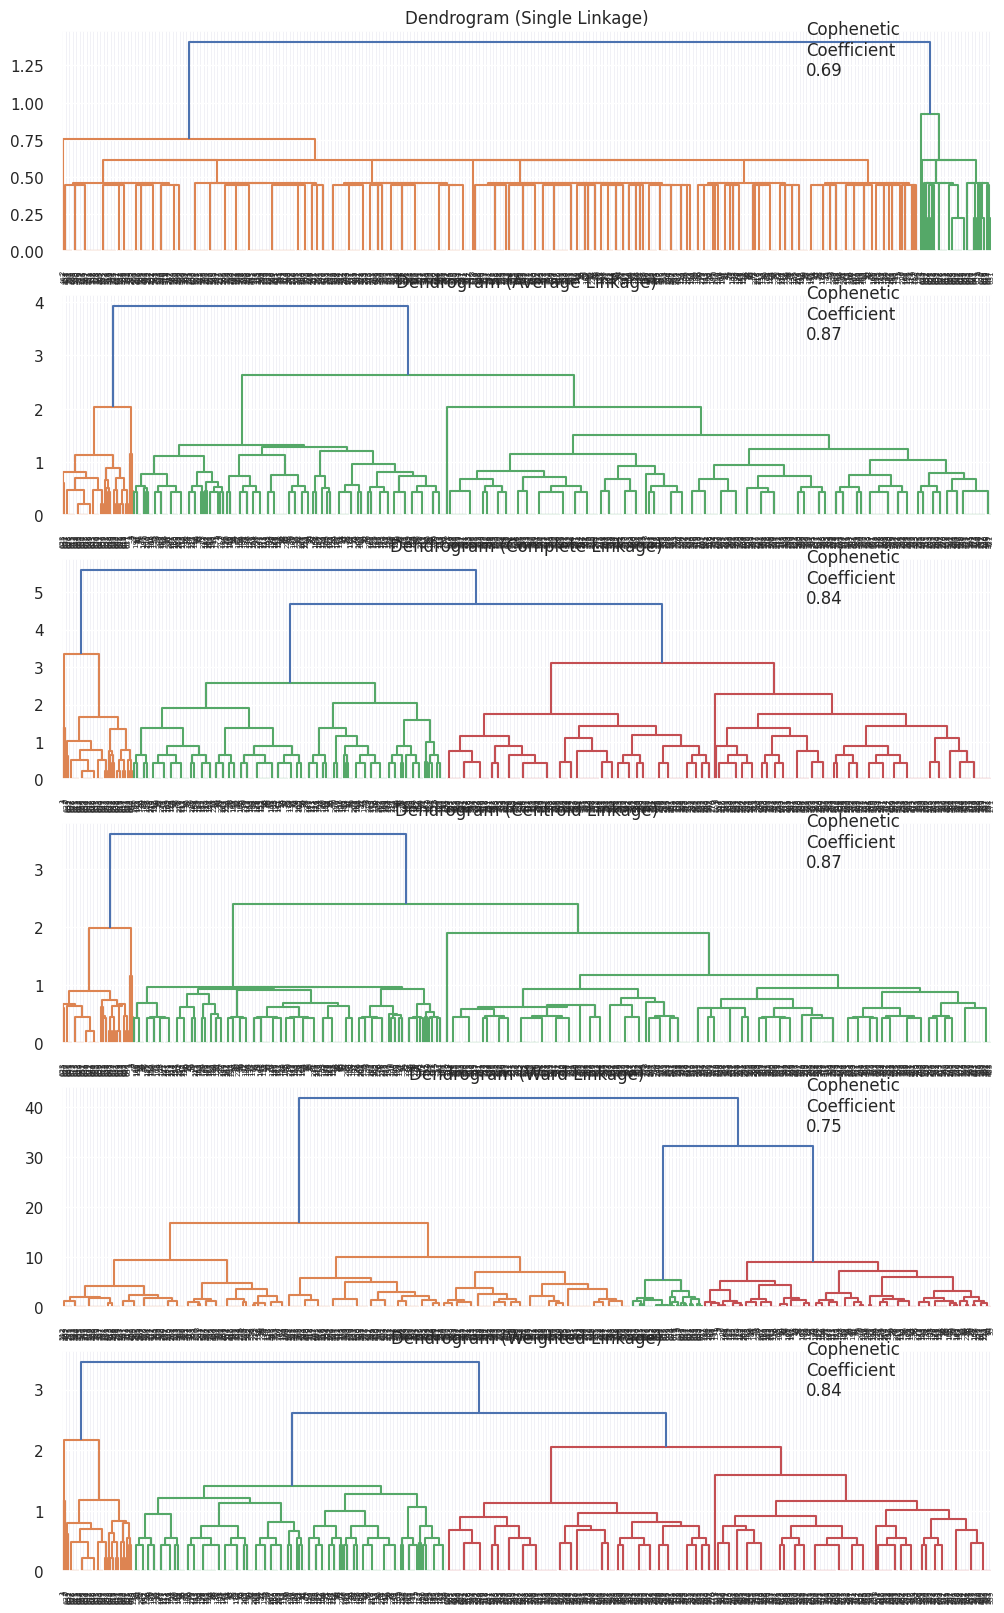

In [89]:
# List of all linkage methods to check
methods = ['single',
           'average',
           'complete',
           'centroid',
           'ward',
          'weighted']

# Calculate the pairwise distance form the dataset to be used in the cophenetic correlation calculation
# Create lists to save results of coph calculation
compare_cols = ['Linkage', 'Cophenetic Coefficient']
compare = []

# Create a subplot image
fig, axs = plt.subplots(len(methods), 1, figsize=(12,20))

# Enumerate through the list of all methods above
# Get linkage, plot dendrogram, calculate cophenetic coefficient
for i, method in enumerate(methods):

    Z = linkage(subset_scaled_df, metric='euclidean', method=method)

    dendrogram(Z, ax=axs[i]);
    axs[i].set_title(f'Dendrogram ({method.capitalize()} Linkage)')
    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df))
    axs[i].annotate(f'Cophenetic\nCoefficient\n{coph_corr:0.2f}',
                    (0.80, 0.80),
                    xycoords='axes fraction')
    compare.append([method, coph_corr])

**Dendogran with `Weigthed, centroid and average Linkage` shows the distintic and separated cluster, which is represented by highest correlation score meaning that the clusters are separated from each other.**

In [96]:
# Create and print dataframe to compare Cophenetic Coefficient for each linkage
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc

,Linkage,Cophenetic Coefficient
0,single,0.685360
1,average,0.870014
2,complete,0.835517
3,centroid,0.867729
4,ward,0.748774
5,weighted,0.844405


### cluster profiling

#### Creating 3 clusters

In [63]:
# Convert the NumPy array back into a Pandas DataFrame
subset_scaled_df = pd.DataFrame(subset_scaled_df)
from sklearn.cluster import AgglomerativeClustering
#Trying with K value as 3
HCmodel = AgglomerativeClustering(n_clusters=3,metric='euclidean', linkage='average')
HCmodel.fit(subset_scaled_df)
subset_scaled_df['HC_Clusters'] = HCmodel.labels_

In [64]:
df_outliers['HC_Clusters'] = HCmodel.labels_

In [68]:
cluster_profile_HC = df_outliers.drop('cc_spending_bin', axis=1).groupby('HC_Clusters').mean()
cluster_profile_HC

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments
HC_Clusters,,,,,,
0,12666.666667,2.413333,0.928889,3.531111,6.840000,0.991111
1,102660.000000,8.740000,0.600000,8.180000,1.080000,2.000000
2,33550.649351,5.522078,3.498701,0.984416,2.005195,0.000000


In [74]:
cluster_profile_HC['Freq'] = df_outliers.groupby('HC_Clusters')['Avg_Credit_Limit'].count().values

In [75]:
# lets display cluster profile
cluster_profile_HC.style.highlight_max(color = 'lightgreen', axis = 0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments,Freq
HC_Clusters,,,,,,,
0,12666.666667,2.413333,0.928889,3.531111,6.840000,0.991111,225
1,102660.000000,8.740000,0.600000,8.180000,1.080000,2.000000,50
2,33550.649351,5.522078,3.498701,0.984416,2.005195,0.000000,385


In [72]:
all_col = df_outliers.columns

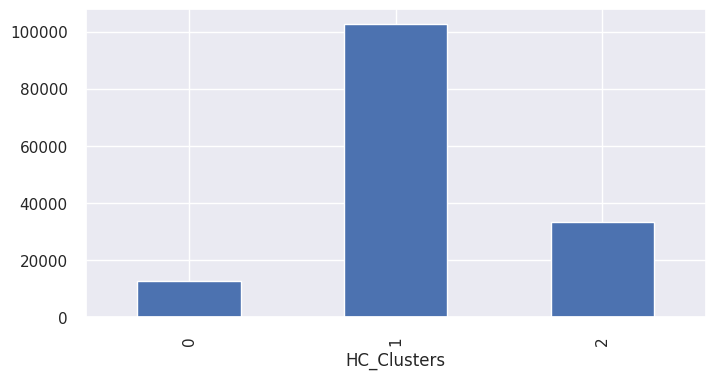

In [73]:
# Checking the groups for Avg_Credit_Limit
cluster_profile_HC['Avg_Credit_Limit'].groupby('HC_Clusters').mean().plot.bar(figsize=(8,4));

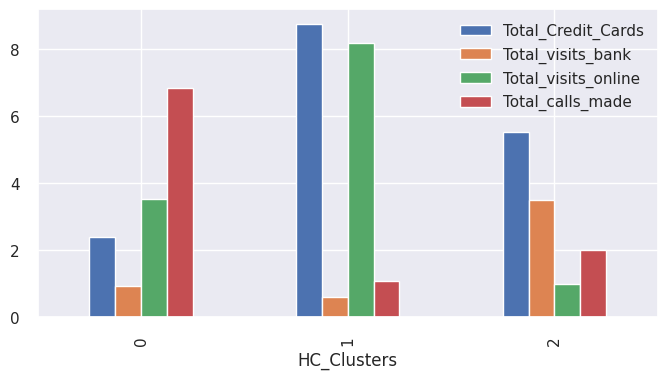

In [76]:
# Checking the groups for the remainder features
cluster_profile_HC[['Total_Credit_Cards', 'Total_visits_bank',
       'Total_visits_online', 'Total_calls_made']].groupby('HC_Clusters').mean().plot.bar(figsize=(8,4));

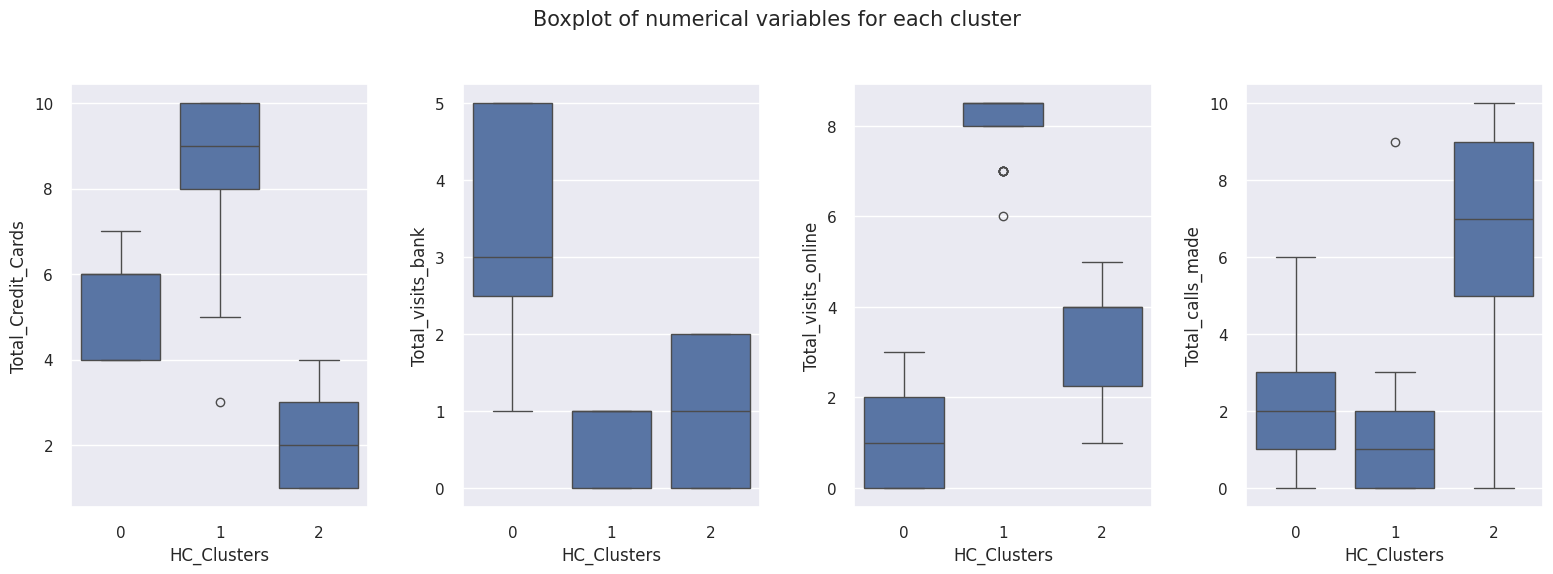

In [113]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6)) # Changed to 4 subplots
fig.suptitle('Boxplot of numerical variables for each cluster', fontsize=15)

# Using the correct number of columns for subset_scaled_df
# subset_scaled_df.columns = df_outliers.columns[1:-2][:4]  # Select first 4 columns
# This line is replaced by the following line to keep the "HC_Clusters" column:
subset_scaled_df = df_outliers[[ 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made', 'HC_Clusters']]
# Subset only the required columns for visualization along with 'HC_Clusters'

for i in range(4):  # Changed loop to iterate 4 times
    sns.boxplot(ax=axes[i], y=subset_scaled_df[subset_scaled_df.columns[i]], x=subset_scaled_df['HC_Clusters'])

fig.tight_layout(pad=2.0)

#### **Insights hierarchical clustering**
- Cluster 0 :
    - `Avg_Credit_Limit:` The lowest end type of client.
    - `Total_Credit_Cards:` The lowest end type of client.
    - `Total_visits_bank:` The lowest end type of client.
    - `Total_visits_online:` The mid end type of client.
    - `Total_calls_made:` The mid end type of client.
- Cluster 1 :
    - `Avg_Credit_Limit:` The highest end type of client.
    - `Total_Credit_Cards:` The mid end type of client.
    - `Total_visits_bank:` The lowest end type of client.
    - `Total_visits_online:` The highest end type of client.
    - `Total_calls_made:` The highest end type of client.
- Cluster 2 :
    - `Avg_Credit_Limit:` The mid end type of client.
    - `Total_Credit_Cards:` The highest end type of client.
    - `Total_visits_bank:` The mid end type of client.
    - `Total_visits_online:` The lowest end type of client.
    - `Total_calls_made:` The lowest end type of client.

### K-means vs Hierarchical Clustering

In [79]:
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments,Freq
K_means_segments,,,,,,,
0,33713.178295,5.511628,3.485788,0.984496,2.005168,0.000000,387
1,12197.309417,2.403587,0.928251,3.553812,6.883408,1.000000,223
2,102660.000000,8.740000,0.600000,8.180000,1.080000,2.000000,50


In [82]:
cluster_profile_HC.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments,Freq
HC_Clusters,,,,,,,
0,12666.666667,2.413333,0.928889,3.531111,6.840000,0.991111,225
1,102660.000000,8.740000,0.600000,8.180000,1.080000,2.000000,50
2,33550.649351,5.522078,3.498701,0.984416,2.005195,0.000000,385


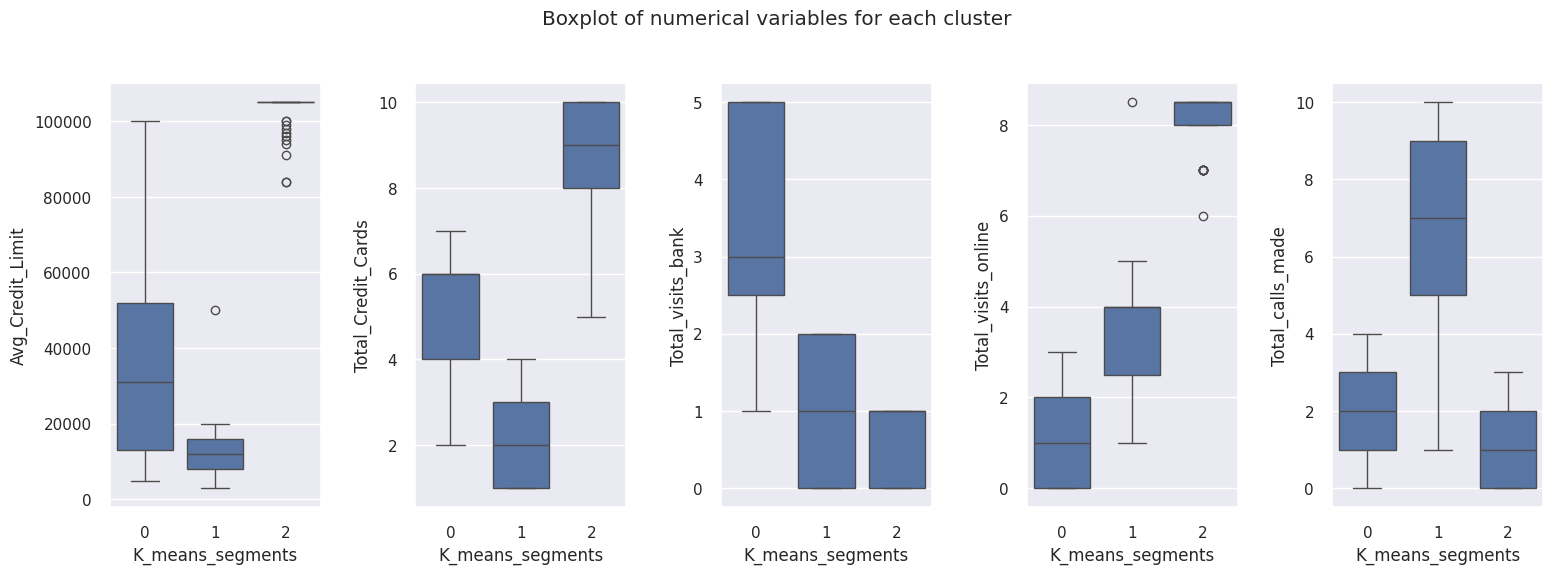

In [83]:
list_columns =  cluster_profile.columns
fig, axes = plt.subplots(1, 5,  figsize=(16, 6))
fig.suptitle('Boxplot of numerical variables for each cluster')
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii],y=df_outliers[list_columns[counter]],x=df_outliers['K_means_segments'])
    counter = counter+1

fig.tight_layout(pad=2.0)

 **Conclusions K-means**

- `Cluster 0` : Seems to be type of clients with the lowest credit limit, more willing to visit the bank.
- `Cluster 1` : Mid range type of client a mix between cluster 2 and cluster 0.
- `Cluster 2` : Seems to be the type of client with the highest credit limit, more willing to use online banking system.

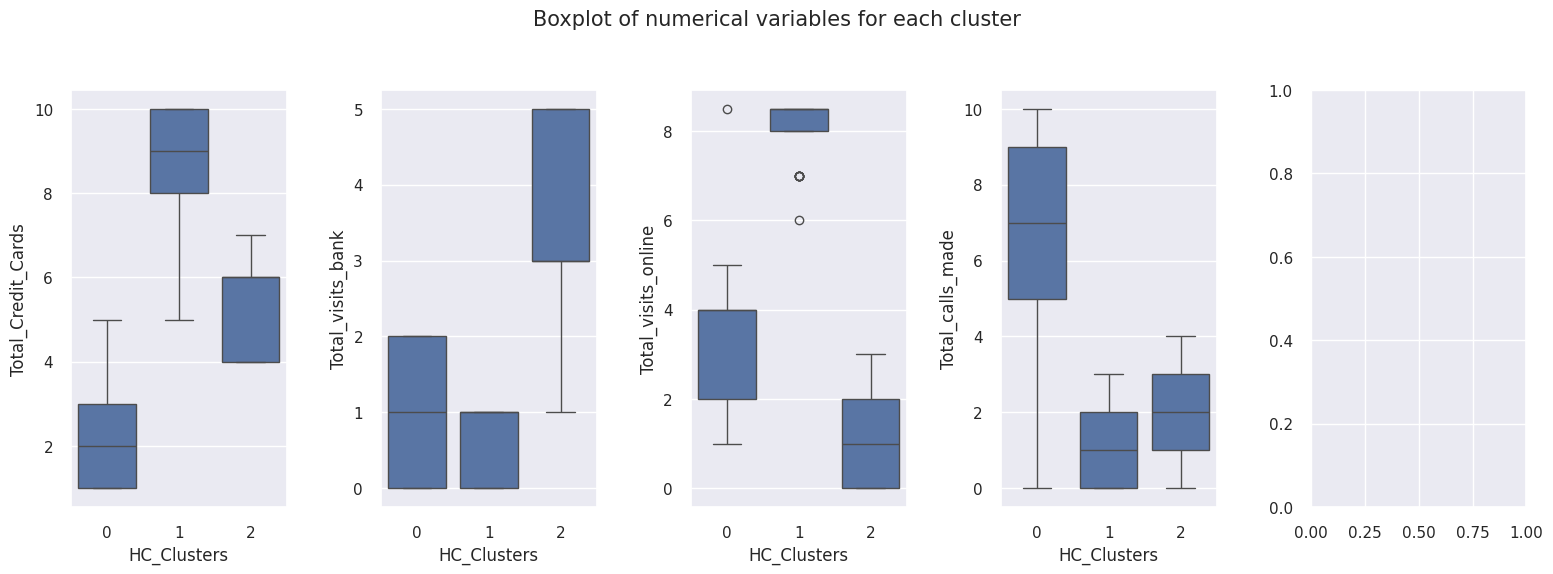

In [85]:
fig, axes = plt.subplots(1, 5,  figsize=(16, 6))
fig.suptitle('Boxplot of numerical variables for each cluster', fontsize=15)
counter = 0

# Ensure subset_scaled_df has the necessary columns for visualization along with 'HC_Clusters'
subset_scaled_df = df_outliers[[ 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made', 'HC_Clusters']]

# Adjust the loop to iterate over correct column names and data:
for ii in range(4):  # Changed loop to iterate 4 times
    sns.boxplot(ax=axes[ii], y=subset_scaled_df[subset_scaled_df.columns[ii]], x=subset_scaled_df['HC_Clusters'])

fig.tight_layout(pad=2.0)

 **Conclusions Hierarchical clusters**
- `Cluster 0` : Seems to be type of clients with the lowest credit limit.
- `Cluster 1` : Seems to be type of clients with the highest credit limit. A client that demands online and mobile contact.
- `Cluster 2` : Seems to be the type of client with the mid credit limit range, a type of client that do not visit the bank neither use the online banking.

## Actionable Insights

3 different clusters with two different methods `kmeans` and `hierarchical clustering`.

1. How are these segments different from each other?

The clusters are divided based on their credit limit and their needs to contact the bank. The client have the option to visit the bank, to use the call center or to use the online banking.

**Insights K-means**
- Cluster 0 :
    - `Avg_Credit_Limit:` The mid end type of client.
    - `Total_Credit_Cards:` The mid end type of client.
    - `Total_visits_bank:` Visit the most the bank.
    - `Total_visits_online:` Doesn't access much the online bank.
    - `Total_calls_made:` Don't call as much as expected.
- Cluster 1 :
    - `Avg_Credit_Limit:` The lowest end type of client.
    - `Total_Credit_Cards:` The lowest end type of client.
    - `Total_visits_bank:` Doesn't visit much the bank.
    - `Total_visits_online:` Average end in terms of online banking usage.
    - `Total_calls_made:` The highest end type of client.
- Cluster 2 :
    - `Avg_Credit_Limit:` The highest end type of client.
    - `Total_Credit_Cards:` The highest end type of client.
    - `Total_visits_bank:` The lowest end type of client.
    - `Total_visits_online:` The highest end type of client.
    - `Total_calls_made:` The lowest end type of client.

**Insights hierarchical clustering**
- Cluster 0 :
    - `Avg_Credit_Limit:` The lowest end type of client.
    - `Total_Credit_Cards:` The lowest end type of client.
    - `Total_visits_bank:` The lowest end type of client.
    - `Total_visits_online:` The mid end type of client.
    - `Total_calls_made:` The mid end type of client.
- Cluster 1 :
    - `Avg_Credit_Limit:` The highest end type of client.
    - `Total_Credit_Cards:` The mid end type of client.
    - `Total_visits_bank:` The lowest end type of client.
    - `Total_visits_online:` The highest end type of client.
    - `Total_calls_made:` The highest end type of client.
- Cluster 2 :
    - `Avg_Credit_Limit:` The mid end type of client.
    - `Total_Credit_Cards:` The highest end type of client.
    - `Total_visits_bank:` The mid end type of client.
    - `Total_visits_online:` The lowest end type of client.
    - `Total_calls_made:` The lowest end type of client.

2. What are your recommendations to the bank on how to better market to and service these customers?

The bank received a lot of complains about their service to clients. However, not every single type of client require "attention" from the bank.
The clusters helped us identify who were clients with the most credit limit, that hold the most credit cards and needed more attention from the bank which would be a group important to explore more their "share of wallet".


**Conclusions K-means**

    - `Cluster 0` : Seems to be type of clients with the lowest credit limit, more willing to visit the bank.
    - `Cluster 1` : Mid range type of client a mix between cluster 2 and cluster 0.
    - `Cluster 2` : Seems to be the type of client with the highest credit limit, more willing to use online banking system.

**Conclusions Hierarchical clusters**

    - `Cluster 0` : Seems to be type of clients with the lowest credit limit.
    - `Cluster 1` : Seems to be type of clients with the highest credit limit. A client that demands online and mobile contact.
    - `Cluster 2` : Seems to be the type of client with the mid credit limit range, a type of client that do not visit the bank neither use the online banking.

**Recommendations**

***Accessing customers with an upper credit limit seems to be the best strategy based on the analysis of the clusters.***

- `Kmeans -> Cluster 2` : Explore online marketing campaigns to this type of client. High financial potential in comparison with others clusters and desirous to access the bank online.

- `Hierarchical -> Cluster 1` : Explore online marketing campaigns to this type of client, and also develop a better approach in the call center. This type of client is willing to access the bank online however needs a better call center service.



## Business Recommendations

**Cluster 0**

This type of customer has a good `Avg_Credit_Limit` and likes to visit the bank in person.
It is important to identify visiting patterns and improve your experience.

**Cluster 1**

This type of customer has a bad `Avg_Credit_Limit` and likes to call the bank. It is important to identify whether they are the type of customer the bank wants to invest in. Mainly because developing a better call center experience can be expensive and customers in this cluster enjoy the phone call experience.

**Cluster 2**

This type of customer has a good `Avg_Credit_Limit` and likes to visit the online bank. It is important to identify patterns of online visits and improve your experience by tracking your internet flow showing new products and services.


**Cluster 3**

This type of customer has a good `Avg_Credit_Limit` and likes to visit the bank in person. It is important to identify visiting patterns and improve their experience.
